In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
movies = pd.read_csv('data/movies.csv')
links = pd.read_csv('data/links.csv') #if we wanted to refer to other websites with ratings for movies there
ratings = pd.read_csv('data/ratings.csv')
tags = pd.read_csv('data/tags.csv')

In [8]:
tags['tag_timestamp'] = pd.to_datetime(tags['timestamp'], unit='s')
tags = tags.drop('timestamp', axis=1)
tags_grouped = tags.groupby(['userId', 'movieId'])['tag'].apply(list).reset_index()

ratings['rating_timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings = ratings.drop('timestamp', axis=1)

df_rt = ratings.merge(tags, on=['userId', 'movieId'], how='left')
df = df_rt.merge(movies, on='movieId', how='left')

In [9]:
cols = [
    'userId', 'movieId', 'title', 'genres', 'rating', 'rating_timestamp', 'tag', 'tag_timestamp'
]
df = df[cols]

In [10]:
# Step 1: Split the genres into lists
df['genres_list'] = df['genres'].str.split('|')

# Step 2: Get dummy variables for each genre
genres_dummies = df['genres_list'].explode().str.get_dummies().groupby(level=0).max().astype(bool)

# Step 3: Concatenate with original dataframe
df_final = pd.concat([df.drop(columns=['genres', 'genres_list']), genres_dummies], axis=1)

In [13]:
df_final.columns

Index(['userId', 'movieId', 'title', 'rating', 'rating_timestamp', 'tag',
       'tag_timestamp', '(no genres listed)', 'Action', 'Adventure',
       'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'],
      dtype='str')

## EDA

C:\Users\atwoo\AppData\Local\Temp\ipykernel_19040\630678146.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


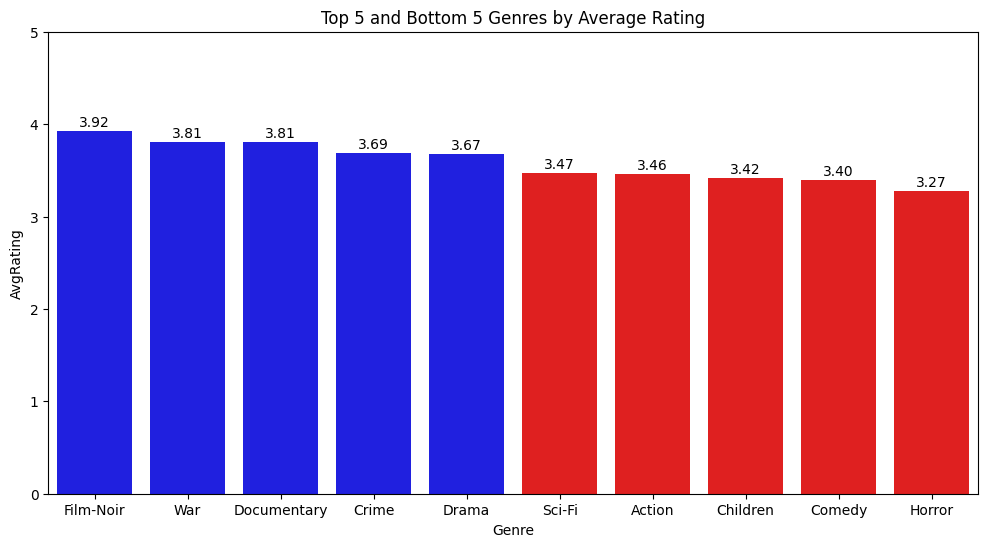

In [24]:
# Step 1: Identify genre columns
genre_cols = ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# Step 2: Compute average rating per genre
genre_avg_rating = {}
for genre in genre_cols:
    # Only consider rows where genre is True
    genre_avg_rating[genre] = df_final.loc[df_final[genre], 'rating'].mean()

genre_avg_rating = pd.Series(genre_avg_rating).sort_values(ascending=False)

# Step 3: Top 5 and bottom 5
top5 = genre_avg_rating.head(5)
bottom5 = genre_avg_rating.tail(5)

# Step 4: Combine for plotting
plot_df = pd.concat([top5, bottom5]).reset_index()
plot_df.columns = ['Genre', 'AvgRating']

# Step 5: Assign colors
plot_df['Color'] = ['blue']*5 + ['red']*5

# Step 6: Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=plot_df, 
    x='Genre', 
    y='AvgRating', 
    palette=plot_df['Color'].tolist()  # <-- convert Series to list
)
plt.title('Top 5 and Bottom 5 Genres by Average Rating')
plt.ylim(0, 5)

# Annotate average rating on bars
for i, row in plot_df.iterrows():
    plt.text(i, row['AvgRating'] + 0.05, f"{row['AvgRating']:.2f}", ha='center')

plt.show()